In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:90% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:12pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:12px;}
table {margin-left:0 !important; margin-right: auto;}
</style>
"""))

<font size="5" color="black">ch1. 허깅페이스 모델 사용</font>
- pipeline(): 모델을 로컬에 다운 후 결과를 출력하는 로컬 사용 방식
- Inference API: HTTP 요청으로 결과만 받아오는 방식



        - 처음 모델 사용 시 "C:/Users/Admin/.cache/huggingface" 다운로드로 시간 소요 발생
        
|**Task**|**설명**|
|:---|:---|
|text-classification (sentiment-analysis) | 감정 분석, 뉴스 분류, 리뷰 분류 등 문장 분류|
|zero-shot-classification | 레이블에 대한 별도 학습 없이 후보 레이블 중에서 분류|
|text-generation | GPT 계열 모델을 이용한 텍스트 생성|
|fill-mask | 문장 안의 빈칸(마스크)에 들어갈 단어 예측|
|ner (token-classification) | 개체명 인식(사람, 조직, 장소 등 라벨링)|
|question-answering | 주어진 지문(context)을 근거로 질문에 답변|
|summarization | 긴 문서를 짧게 요약|
|translation | 서로 다른 언어 간 번역|
|image-to-text | 이미지 내용을 설명하는 문장 생성|
|image-classification | 이미지가 어떤 대상인지 분류|



In [47]:
import warnings
import os
import logging
 
# 경고 메시지 제거
warnings.filterwarnings('ignore')
 
# transformers 라이브러리의 로깅 레벨을 ERROR로 조정 (경고 숨김)
logging.getLogger("transformers").setLevel(logging.ERROR)
 
# Hugging Face 캐시 관련 symlink 경고 제거
os.environ['HF_HUB_DISABLE_SYMLINKS_WARNING'] = '1'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# 1. TEXT 기반 감정 분석
- 감성 분석(Sentiment Analysis) : 텍스트에 들어있는 작성자의 태도, 의견, 감정 상태(긍정, 부정, 중립 등)를 컴퓨터가 자동으로 판별해내는 자연어 처리(NLP) 기술


    - pipeline() : 토큰화 → 워드 임베딩 → 모델 → 예측

In [3]:
from transformers import pipeline
classifier = pipeline(
    task="text-classification",
    model="distilbert-base-uncased-finetuned-sst-2-english")
classifier("I've been waiting for a Hugging face course my whole life")

Device set to use cpu


[{'label': 'POSITIVE', 'score': 0.9982088804244995}]

In [4]:
# 모델의 파라미터와 용량
from transformers import AutoModel
model = AutoModel.from_pretrained("distilbert-base-uncased-finetuned-sst-2-english")

# 전체 파라미터 수
total_params = sum(p.numel() for p in model.parameters())

In [5]:
print(f"전체 파라미터 수: {total_params:,}")
print(f"전체 파라미터 용량: {total_params/1024/1024:.3f}MB")

전체 파라미터 수: 66,362,880
전체 파라미터 용량: 63.289MB


In [6]:
from transformers import pipeline
classifier = pipeline(
    task="sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english")

# 다항의 경우 list
classifier([
    "I've been waiting for a Hugging face course my whole life",
    "I hate this"
])

Device set to use cpu


[{'label': 'POSITIVE', 'score': 0.9982088804244995},
 {'label': 'NEGATIVE', 'score': 0.9996224641799927}]

In [7]:
classifier([
    "I've been waiting for a Hugging face course my whole life",
    "이 영화는 재미 없었어요" # 영어로 학습한 모델 : 한국어에 대한 정확도는 낮은 편
]) 

[{'label': 'POSITIVE', 'score': 0.9982088804244995},
 {'label': 'POSITIVE', 'score': 0.879510760307312}]

In [8]:
classifier = pipeline(
    task="sentiment-analysis",
    model="daekeun-ml/koelectra-small-v3-nsmc")
text = ['힘들어요','오늘 기분 좋은데','너 싫어','내가 최고야']
classifier(text)

Device set to use cpu


[{'label': '0', 'score': 0.9957089424133301},
 {'label': '1', 'score': 0.9966667294502258},
 {'label': '0', 'score': 0.9964488744735718},
 {'label': '1', 'score': 0.9213551878929138}]

In [9]:
for text, result in zip(text, classifier(text)):
    label = "긍정" if result['label']=='1' else '부정'
    print(f"'{text}' → {label} {result['score']:.2%}")

'힘들어요' → 부정 99.57%
'오늘 기분 좋은데' → 긍정 99.67%
'너 싫어' → 부정 99.64%
'내가 최고야' → 긍정 92.14%


# 2. Zero-shot 분류
- Zero-shot 분류 : 사전 학습 과정에서 본 적 없는 새로운 범주의 데이터를 추가 학습이나 훈련 데이터(Zero-shot = 0개의 학습 데이터) 없이 분류해내는 머신러닝 기법

In [10]:
classifier = pipeline(
    task='zero-shot-classification',
    model='facebook/bart-large-mnli')

classifier(
    "I have a problem with my i-phone that needs to be resolved asap!!",
    candidate_labels=['phone', 'urgent', 'tablet', 'computer'] # 주제 제시
          )

Device set to use cpu


{'sequence': 'I have a problem with my i-phone that needs to be resolved asap!!',
 'labels': ['urgent', 'phone', 'computer', 'tablet'],
 'scores': [0.5815838575363159,
  0.41218551993370056,
  0.004297187551856041,
  0.0019334867829456925]}

In [11]:
classifier(
    "This is a course about the Tranformers library",
    candidate_labels=['education','business','phone']
)

{'sequence': 'This is a course about the Tranformers library',
 'labels': ['education', 'business', 'phone'],
 'scores': [0.8435037136077881, 0.09626130014657974, 0.06023499742150307]}

# 3. TEXT 생성
- openai-community gpt2 : 자공귀적(Autoregressive) 언어 모델
    - 트랜스포머 디코더(Transformer Decoder) 기반
    - 무감독 학습(Unsupervised Pre-training)
    - 파라미터 규모 확장의 증명
    
- 파인 튜닝(Fine-tuning)할 때는 단순히 모델 자체를 메모리(VRAM)에 올릴 때보다 최소 3~4배 이상의 추가 GPU 메모리가 필요
    - 그래디언트
    - 옵티마이저 상태
    - 활성화 값
    - 임시 버퍼 및 메모리 파편화

In [12]:
# 모델의 파라미터와 용량
from transformers import AutoModel
model = AutoModel.from_pretrained("gpt2")

# 전체 파라미터 수
total_params = sum(p.numel() for p in model.parameters())
print(f"전체 파라미터 수: {total_params:,}")
print(f"전체 파라미터 용량: {total_params/1024/1024:.3f}MB")

전체 파라미터 수: 124,439,808
전체 파라미터 용량: 118.675MB


In [14]:
generator = pipeline(
    task="text-generation",
    model="gpt2")

generator("In this course, We will teach you how to",
         pad_token_id=generator.tokenizer.eos_token_id)

Device set to use cpu


[{'generated_text': 'In this course, We will teach you how to create a Java project using OCaml to create a Java app that generates a Java bytecode file.\n\nHere is the code:\n\n<?xml version="1.0" encoding="UTF-8"?> <code> <summary> <description>A Java app to generate bytecode files.</description> <code> <description>A Java app to generate a Java bytecode file.</code> <code> <description>A Java app to generate a Java bytecode file.</code> <code> <description>A Java app to generate a Java bytecode file.</code> <code> <description>A Java app to generate a Java bytecode file.</code> <code> <description>A Java app to generate a Java bytecode file.</code> <code> <description>A Java app to generate a Java bytecode file.</code> </summary> </code>\n\nOnce this is completed, we will start to generate the bytecode file using the OCaml runtime. We will then create a project using the OCaml package.\n\nIn this course, we will generate the bytecode file using the OCaml runtime. As you can see, the

In [15]:
result = generator(
    "In this course, We will teach you how to",
    pad_token_id=generator.tokenizer.eos_token_id)
print(result[0]['generated_text'])

In this course, We will teach you how to create a "real-life" video game. We will teach you how to create a Real-Life video game.

How to Create a Game with Physics:

Here are the steps to create a game with physics:

Step 1: Create a Game with Physics

Step 2: Create a Physics Game

Step 3: Create an Game with Physics

Step 4: Create a Game with Physics and Physics

Step 5: Create a Game with Physics

Step 6: Create a Game with Physics and Physics and Physics

Step 7: Create a Game with Physics and Physics and Physics and Physics

Step 8: Create a Game with Physics and Physics and Physics and Physics and Physics and Physics and Physics and Physics and Physics and Physics

Step 9: Create a Game with Physics and Physics and Physics and Physics and Physics and Physics and Physics and Physics

Step 10: Create a Game with Physics and Physics and Physics and Physics and Physics and Physics and Physics and Physics and Physics and Physics and Physics

Step 11: Create a Game with Physics and P

In [28]:
from transformers import pipeline
generator = pipeline(
    task="text-generation",
    model="skt/kogpt2-base-v2",
    device = -1 # gpu 사용 시 0
)

prompt = "이 과정은 다음과 같은 것을 훈련합니다."

result = generator(
    prompt,
    pad_token_id=generator.tokenizer.eos_token_id,
    max_new_tokens=20, # 새롭게 생성할 단어(토큰)의 최대 개수를 20개로 제한
    do_sample=True, # 다양한 단어를 선택하는 샘플링 방식
    top_k=50, # 상위 50개 확률 단어 중에서만 선택
    top_p=0.92, # 누적 확률 92% 내 단어 중에서 선택
    temperature=0.8, # 1.0보다 낮으면 더 창의적이고 정돈된 문장 생성
    repetition_penalty=1.2 # 반복 문구 생성 억제
)
print(result[0]['generated_text'])

Device set to use cpu


이 과정은 다음과 같은 것을 훈련합니다. 따라서 다른 사람들과의 관계를 잘 맺는 데 도움이 되는 것입니다."
이렇게 하여 사람들은 서로에 대해 더


# 4. 마스크 채우기

In [51]:
unmasker = pipeline(
    task="fill-mask",
    model="distilbert/distilroberta-base"
)

unmasker("I'm going to hospital and meet a <mask>", top_k=2)

[{'score': 0.19275875389575958,
  'token': 3299,
  'token_str': ' doctor',
  'sequence': "I'm going to hospital and meet a doctor"},
 {'score': 0.06794668734073639,
  'token': 27321,
  'token_str': ' psychiatrist',
  'sequence': "I'm going to hospital and meet a psychiatrist"}]

In [30]:
unmasker("병원에서 <mask>를 만날 예정이에요")

[{'score': 0.2404123991727829,
  'token': 1437,
  'token_str': ' ',
  'sequence': '병원에서 를 만날 예정이에요'},
 {'score': 0.07150343805551529,
  'token': 12,
  'token_str': '-',
  'sequence': '병원에서-를 만날 예정이에요'},
 {'score': 0.03956756368279457,
  'token': 193,
  'token_str': ' 2017',
  'sequence': '병원에서 2017를 만날 예정이에요'},
 {'score': 0.03611239790916443,
  'token': 199,
  'token_str': ' 2018',
  'sequence': '병원에서 2018를 만날 예정이에요'},
 {'score': 0.03258509561419487,
  'token': 2,
  'token_str': '</s>',
  'sequence': '병원에서를 만날 예정이에요'}]

In [52]:
# unmasker = pipeline(
#     task="fill-mask",
#     model="google-bert/bert-base-uncased" - 고용량의 모델은 일부 환경에서 활용이 어려움
# )

# unmasker("Hello, I'm a [MASK] model.", top_k=2)

## inference API
- 실시간으로 모델의 예측 및 생성 결과를 받아볼 수 있게 해주는 서비스.

In [33]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [36]:
from huggingface_hub import InferenceClient
client = InferenceClient(
    provider='hf-inference',
#     api_key=os.getenv('HF_TOKEN')
)
result = client.fill_mask("Hello, I'm a [MASK] model.",
                         model='google-bert/bert-base-uncased') 
result

[FillMaskOutputElement(score=0.1441427320241928, sequence="hello, i ' m a role model.", token=2535, token_str='role', fill_mask_output_token_str=None),
 FillMaskOutputElement(score=0.14175812900066376, sequence="hello, i ' m a fashion model.", token=4827, token_str='fashion', fill_mask_output_token_str=None),
 FillMaskOutputElement(score=0.06221463158726692, sequence="hello, i ' m a new model.", token=2047, token_str='new', fill_mask_output_token_str=None),
 FillMaskOutputElement(score=0.04102848470211029, sequence="hello, i ' m a super model.", token=3565, token_str='super', fill_mask_output_token_str=None),
 FillMaskOutputElement(score=0.02591117098927498, sequence="hello, i ' m a business model.", token=2449, token_str='business', fill_mask_output_token_str=None)]

In [49]:
# 다국어 바인딩을 지원하는 mask 모델
from transformers import pipeline

unmasker = pipeline(
    "fill-mask",
    "google-bert/bert-base-multilingual-cased"
)

result = unmasker('안녕하세요, 저는 [MASK] 연구원 입니다.', top_k=3)

In [50]:
[r['sequence']for r in result]

['안녕하세요, 저는 대학 연구원 입니다.', '안녕하세요, 저는 연구 연구원 입니다.', '안녕하세요, 저는 이 연구원 입니다.']

# 5. 개체명 인식(NER)
- NER : Named Entity Recognition

In [48]:
ner = pipeline(
    "ner",
    "dbmdz/bert-large-cased-finetuned-conll03-english",
    grouped_entities=True # 객체 그룹화 여부
)

ner('My name is Sylvain and I work at Hugging Face in Brooklyn.')

[{'entity_group': 'PER',
  'score': np.float32(0.9981694),
  'word': 'Sylvain',
  'start': 11,
  'end': 18},
 {'entity_group': 'ORG',
  'score': np.float32(0.9796019),
  'word': 'Hugging Face',
  'start': 33,
  'end': 45},
 {'entity_group': 'LOC',
  'score': np.float32(0.9932106),
  'word': 'Brooklyn',
  'start': 49,
  'end': 57}]

# 6. 질의 응답
- CONTEXT에 대한 질의 응답

In [54]:
q_a = pipeline(
    "question-answering", 
    "distilbert/distilbert-base-cased-distilled-squad"
)

In [55]:
q_a(
    question="Where do I work?",
    context="My name is Sylvain and I work at Hugging Face in Brooklyn." # 질문에 대해, context 내에서 답을 찾음
)

{'score': 0.6385914087295532, 'start': 33, 'end': 45, 'answer': 'Hugging Face'}

In [56]:
context = "My name is Sylvain and I work at Hugging Face in Brooklyn."
context[33:45]

'Hugging Face'

# 7. 문서 요약
- torch ver 2.6 아래의 경우, 문서 요약 실행 불가

In [57]:
summarizer = pipeline("summarization",
                     "facebook/bart-large-cnn")
summary = summarizer('''
Nuri Rocket Prepares for Next Launch with 15 Satellites Assembled at Naro Space Center
GOHEUNG — South Korea's native space launch vehicle, Nuri (KSLV-II), has entered its final launch preparation phase at the Naro Space Center in Goheung, South Jeolla Province. All 15 satellites scheduled for the upcoming mission have gathered at the center, marking one month ahead of the scheduled launch.
This upcoming mission marks the first time Nuri will carry multiple primary satellites simultaneously, deploying advanced precision separation technologies to insert them into targeted orbits. Additionally, Hanwha Aerospace, the lead enterprise integrator, is set to significantly expand its operational role in launch control.
According to the Korea Aerospace Research Institute (KARI) Korea Space Launch Vehicle Program Office on the 7th, 5 primary neonstat microsatellites (Nos. 2–6) and 10 cube secondary satellites were delivered to the assembly facility. The primary satellites completed a two-week self-inspection with no issues detected, while the secondary satellites were assembled into launch tubes following delivery.
KARI plans to integrate the primary payload into the launch vehicle structure this week. &quot;Once this phase is complete, the fairing (satellite protective shroud) will be attached to the third stage in mid-September,&quot; said Park Jong-chan, head of the KARI Program Office. &quot;By late September, full assembly of the first, second, and third stages will be completed.&quot;
A key technological highlight for this launch is the precision attitude control separation technology integrated into the third stage. Because microsatellite constellations operate along the same orbit at designated intervals to perform multiple observations of a single location, precise deployment without in-orbit collisions is critical.
Furthermore, Hanwha Aerospace will take on a greater role as part of South Korea's transition toward a 'New Space' industry model. Hanwha personnel will operate 75% of the launch control center equipment under KARI supervision, with their operational scope set to expand further in subsequent missions.
''',
          max_length=150,
          min_length=30,
          do_sample=True)

In [58]:
summary

[{'summary_text': 'Nuri Rocket Prepares for Next Launch with 15 Satellites Assembled at Naro Space Center. All 15 satellites scheduled for the upcoming mission have gathered at the center. This upcoming mission marks the first time Nuri will carry multiple primary satellites.'}]

# 8. 번역

In [59]:
translator = pipeline(
    "translation",
    "Helsinki-NLP/opus-mt-fr-en"
)

In [60]:
translator('Ce cours est produit par Hugging Face')

[{'translation_text': 'This course is produced by Hugging Face'}]

In [61]:
# 한 → 영
ko2en = pipeline("translation", model="Helsinki-NLP/opus-mt-ko-en")
# 영 → 한
en2ko = pipeline("translation", model="Helsinki-NLP/opus-mt-tc-big-en-ko")

In [62]:
# 테스트 문장
ko_sentence = "이 문장을 영어로 번역해주세요"
en_sentence = "I enjoy learning about AI"

In [64]:
# 번역
print("한→영 :", ko2en(ko_sentence)[0]['translation_text'])
print("영→한 :", en2ko(en_sentence)[0]['translation_text'])

한→영 : Please translate this sentence into English.
영→한 : US  풍선 행


In [67]:
result = ko2en([
    '안녕하세요, 즐거운 하루 보내세요',
    '내일부터 OpenAI API를 학습합니다',
    '사용 결제를 위한 체크카드를 지참해주세요'
])

[r['translation_text'] for r in result]

['Hello. Have a good day.',
 "I'm learning OpenAI APls tomorrow.",
 'Please check your checkcards for the available payment.']

# 9. 이미지를 설명하는 텍스트 생성

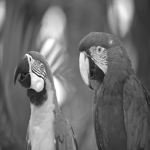

In [79]:
url = 'https://huggingface.co/datasets/Narsil/image_dummy/resolve/main/parrots.png'
from PIL import Image
import requests

response = requests.get(
    url, 
    stream=True, #
).raw

image = Image.open(response)
image = image.resize((150,150))
image

In [80]:
from transformers import pipeline
imagetotext = pipeline(
    "image-to-text",
    "ydshieh/vit-gpt2-coco-en"
)

imagetotext(url, max_new_tokens=30)

[{'generated_text': 'two birds are standing next to each other '}]

In [81]:
url = "http://images.cocodataset.org/val2017/000000039769.jpg"

response = requests.get(
    url, 
    stream=True, #
).raw

image = Image.open(response)
imagetotext(url, max_new_tokens=300)

[{'generated_text': 'a cat laying on a blanket next to a cat laying on a bed '}]

# 10. 이미지 분류

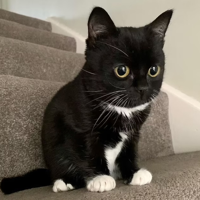

In [82]:
image = Image.open('images/cat.jpg')
image.resize((200,200))

In [83]:
imgclassifier = pipeline(
    "image-classification",
    "google/vit-base-patch16-224"
)

imgclassifier(image)

[{'label': 'Egyptian cat', 'score': 0.8531318306922913},
 {'label': 'tabby, tabby cat', 'score': 0.047503840178251266},
 {'label': 'tiger cat', 'score': 0.03486618027091026},
 {'label': 'Persian cat', 'score': 0.007555845659226179},
 {'label': 'Siamese cat, Siamese', 'score': 0.0037885899655520916}]